# Load the uploaded Excel file & import Library

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'sell.xlsx'
df =  pd.read_excel(file_path)




In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2081 entries, 0 to 2080
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created At         2081 non-null   object 
 1   Approved At        2081 non-null   object 
 2   Order ID           2081 non-null   int64  
 3   Tracking Code      2078 non-null   object 
 4   Invoice            1667 non-null   object 
 5   Recipient Name     2081 non-null   object 
 6   Recipient Phone    2078 non-null   object 
 7   Recipient Address  2078 non-null   object 
 8   Delivery Status    2081 non-null   object 
 9   Approval Status    2081 non-null   object 
 10  Rider              2081 non-null   object 
 11  Riders Phone       2081 non-null   float64
 12  COD Amount         2064 non-null   float64
 13  Shipping Charge    2074 non-null   float64
 14  COD Charge         2064 non-null   float64
 15  Payment Status     2081 non-null   object 
 16  Note               2074 

In [94]:
# # Drop unnecessary columns
# columns_to_drop = [
#     'Created At', 'Approved At', 'Tracking Code', 'Invoice', 
#     'Delivery Status', 'Approval Status', 'Rider', 
#     'Riders Phone', 'Shipping Charge', 'COD Charge', 'Payment Status'
# ]
# df_cleaned = df.drop(columns=columns_to_drop).copy()


In [95]:
# df_cleaned.info()

In [96]:
# df_cleaned

In [97]:
# import re

# # Extract 'Size' from the 'Note' column
# df_cleaned['Size'] = df_cleaned['Note'].str.extract(
#     r'SIZE:\s*(.*?)\s*(?:<br>|-|COLOR|$)', flags=re.IGNORECASE
# )[0]  # Select the first capturing group

# # Fill NaN values with an empty string
# df_cleaned['Size'] = df_cleaned['Size'].fillna('')

# # Extract 'Color' from the 'Note' column
# df_cleaned['Color'] = df_cleaned['Note'].str.extract(
#     r'COLOR:\s*(.*?)\s*(?:<br>|$)', flags=re.IGNORECASE
# )[0]  # Select the first capturing group

# # Fill NaN values with an empty string
# df_cleaned['Color'] = df_cleaned['Color'].fillna('')

# # Display the updated DataFrame
# df_cleaned.head()

# Converting Column Name

In [98]:

duplicates = df[df.duplicated(subset=['Recipient Name', 'Created At'], keep=False)]
duplicates = duplicates.sort_values(by=['Recipient Name', 'Created At'])
duplicates.reset_index(drop=True, inplace=True)
duplicates = duplicates.rename(columns={'Recipient Name': 'Name', 'Created At': 'Date', 'Price': 'Price', 'Quantity': 'Quantity'})
duplicates['Total'] = duplicates['COD Amount'] 
duplicates['Total'] = duplicates['Total'].round(2)

# Drop unnecessary columns

In [99]:
columns_to_keep = [
    'Created At', 'COD Amount', 'Shipping Charge', 'Payment Status',
    'Delivery Status', 'Recipient Address', 'Note'
]
df_cleaned = df[columns_to_keep].copy()
df_cleaned['Created At'] = pd.to_datetime(df_cleaned['Created At'], errors='coerce')

C:\Users\MD ASHRAFUL ISLAM\AppData\Local\Temp\ipykernel_2236\4104183265.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['Created At'] = pd.to_datetime(df_cleaned['Created At'], errors='coerce')


# Extract Size and Color from 'Note'

In [100]:
import re

def extract_size(note):
    size_match = re.search(r'SIZE[:\s]*([0-9]+)', str(note))
    return size_match.group(1) if size_match else None

def extract_color(note):
    color_match = re.search(r'COLOR[:\s]*([A-Z0-9-]+)', str(note))
    return color_match.group(1) if color_match else None

df_cleaned['Size'] = df_cleaned['Note'].apply(extract_size)
df_cleaned['Color'] = df_cleaned['Note'].apply(extract_color)

In [101]:
df_cleaned

,Created At,COD Amount,Shipping Charge,Payment Status,Delivery Status,Recipient Address,Note,Size,Color
0,2024-02-23 17:03:02,1260.0,110.0,Paid,Delivered,36 number house 8 number road C block Banasree...,SIZE: 32\nCOLOR: BN-07 - CBM,32,BN-07
1,2024-02-23 17:37:52,1220.0,110.0,Paid,Delivered,"Joina Bazar, Sripur\nGhazipur",Cod 1220 taka hobe..\nSIZE: 30\nCOLOR: BN-02\n...,30,BN-02
2,2024-02-23 17:40:28,1460.0,110.0,Paid,Delivered,Plain Mosque adjacent to Newmarket Gauchia\nDh...,SIZE: 42\nCOLOR: BN-06 - CBM,42,BN-06
3,2024-02-23 17:42:38,1220.0,110.0,Paid,Delivered,Munshi Road Chatkhil Noakhali\nNoakhali,SIZE: 28\nCOLOR: BN-07 -,28,BN-07
4,2024-02-24 18:21:46,1220.0,110.0,Paid,Delivered,Asa gabua branch Mirzagonj Patualhali\nPatuakhali,SIZE: 30\nCOLOR: BN-02 -,30,BN-02
...,...,...,...,...,...,...,...,...,...
2076,2025-04-21 12:09:16,1260.0,110.0,Paid,Delivered,"Thikana:- Dist.Chandpur, Upz.Kachua, home:- ba...","BN-8 \n34""--1pis -",None,None
2077,2025-04-21 12:11:01,150.0,110.0,Paid,Delivered,"Chittagong Panchlais Atra Depot, Chittagong-","Eta Exchange Parcel Hobe\nBN-1--32"" - CBM",None,None
2078,2025-04-21 12:12:28,1150.0,110.0,Unpaid,Delivered,"Laxmipur Dalalbazar, Laxmipur-",BN-6-28s -,None,None
2079,2025-04-21 15:28:34,3690.0,110.0,Unpaid,Delivered,"Sadhlapur Sheikh Dui Ghar, Gaibandha District-",BN_21-32s-2pice +36s 1 pice total=3 pice 3690tk -,None,None


# Extract Area from Address 

In [102]:

def extract_area(address):
    if pd.isna(address):
        return None
    parts = str(address).split('\n')
    return parts[-1].strip() if len(parts) > 0 else None

df_cleaned['Area'] = df_cleaned['Recipient Address'].apply(extract_area)



In [103]:
df_cleaned.head()

,Created At,COD Amount,Shipping Charge,Payment Status,Delivery Status,Recipient Address,Note,Size,Color,Area
0,2024-02-23 17:03:02,1260.0,110.0,Paid,Delivered,36 number house 8 number road C block Banasree...,SIZE: 32\nCOLOR: BN-07 - CBM,32,BN-07,36 number house 8 number road C block Banasree...
1,2024-02-23 17:37:52,1220.0,110.0,Paid,Delivered,"Joina Bazar, Sripur\nGhazipur",Cod 1220 taka hobe..\nSIZE: 30\nCOLOR: BN-02\n...,30,BN-02,Ghazipur
2,2024-02-23 17:40:28,1460.0,110.0,Paid,Delivered,Plain Mosque adjacent to Newmarket Gauchia\nDh...,SIZE: 42\nCOLOR: BN-06 - CBM,42,BN-06,Dhaka District Newmarket Police Station
3,2024-02-23 17:42:38,1220.0,110.0,Paid,Delivered,Munshi Road Chatkhil Noakhali\nNoakhali,SIZE: 28\nCOLOR: BN-07 -,28,BN-07,Noakhali
4,2024-02-24 18:21:46,1220.0,110.0,Paid,Delivered,Asa gabua branch Mirzagonj Patualhali\nPatuakhali,SIZE: 30\nCOLOR: BN-02 -,30,BN-02,Patuakhali


In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")



## visualization

## 1. Top Selling Sizes

C:\Users\MD ASHRAFUL ISLAM\AppData\Local\Temp\ipykernel_2236\3223954766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_counts.index, y=size_counts.values, palette="Blues_r")


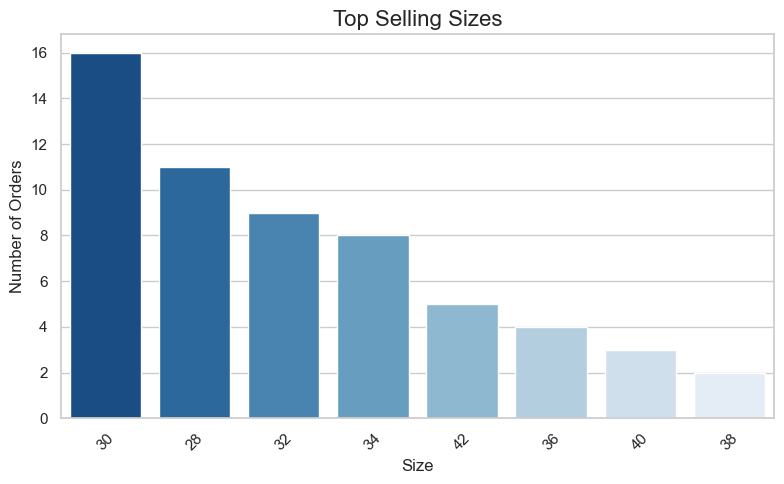

In [105]:

plt.figure(figsize=(8, 5))
size_counts = df_cleaned['Size'].value_counts().sort_values(ascending=False)
sns.barplot(x=size_counts.index, y=size_counts.values, palette="Blues_r")
plt.title("Top Selling Sizes", fontsize=16)
plt.xlabel("Size")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top Selling Colors

C:\Users\MD ASHRAFUL ISLAM\AppData\Local\Temp\ipykernel_2236\3684275920.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.index, y=color_counts.values, palette="Purples_r")


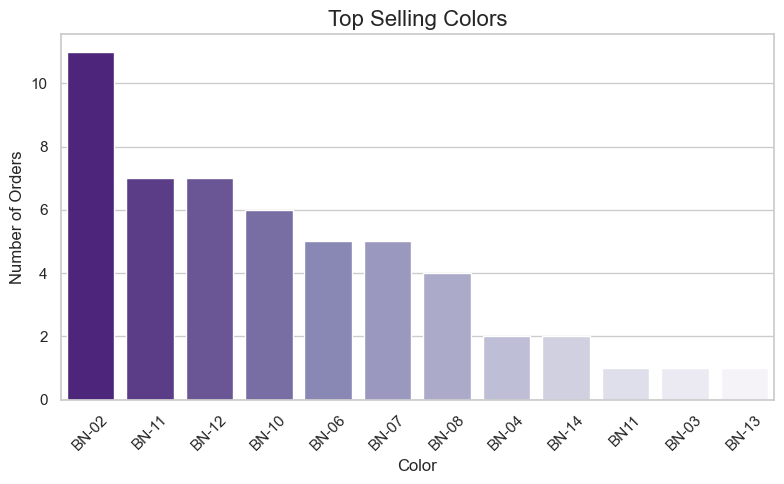

In [106]:

plt.figure(figsize=(8, 5))
color_counts = df_cleaned['Color'].value_counts().sort_values(ascending=False)
sns.barplot(x=color_counts.index, y=color_counts.values, palette="Purples_r")
plt.title("Top Selling Colors", fontsize=16)
plt.xlabel("Color")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Monthly Sales Trend

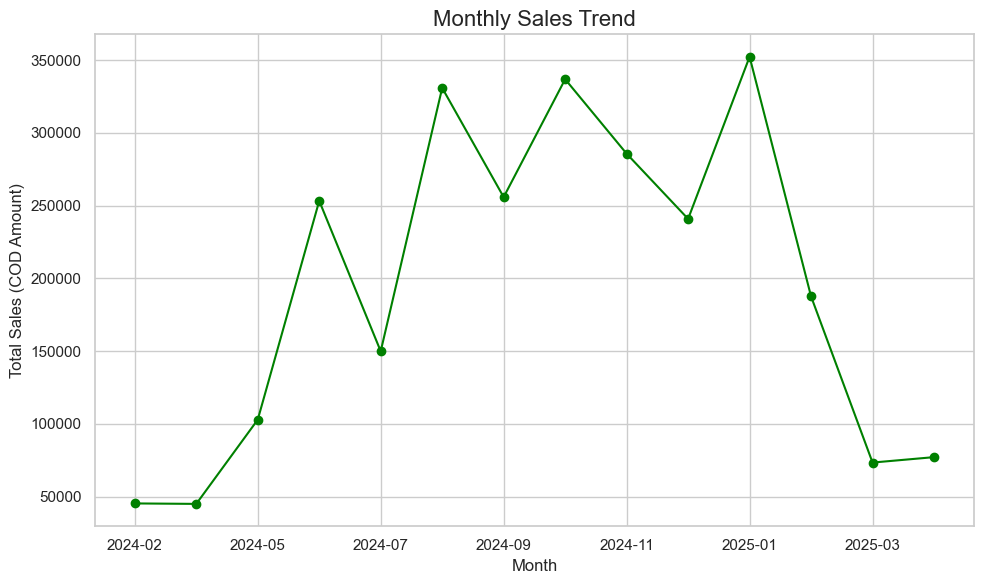

In [107]:

df_cleaned['Month'] = df_cleaned['Created At'].dt.to_period('M').astype(str)
monthly_sales = df_cleaned.groupby('Month')['COD Amount'].sum()

plt.figure(figsize=(10, 6))
monthly_sales.plot(marker='o', color='green')
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales (COD Amount)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Payment Status (Paid vs Unpaid)

C:\Users\MD ASHRAFUL ISLAM\AppData\Local\Temp\ipykernel_2236\1475078573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="Set2")


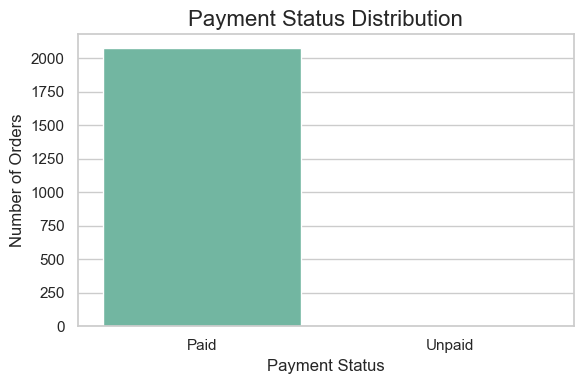

In [108]:

plt.figure(figsize=(6, 4))
payment_counts = df_cleaned['Payment Status'].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="Set2")
plt.title("Payment Status Distribution", fontsize=16)
plt.ylabel("Number of Orders")
plt.xlabel("Payment Status")
plt.tight_layout()
plt.show()

## 5. Top Areas by Orders

C:\Users\MD ASHRAFUL ISLAM\AppData\Local\Temp\ipykernel_2236\806140949.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_areas.index, x=top_areas.values, palette="Oranges_r")


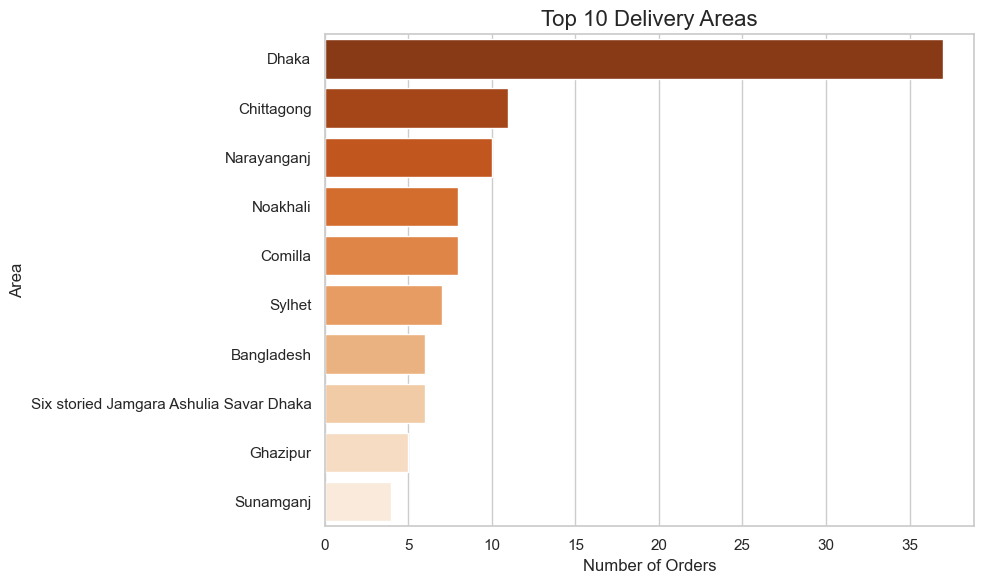

In [109]:

plt.figure(figsize=(10, 6))
top_areas = df_cleaned['Area'].value_counts().head(10)
sns.barplot(y=top_areas.index, x=top_areas.values, palette="Oranges_r")
plt.title("Top 10 Delivery Areas", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Area")
plt.tight_layout()
plt.show()



# Find the top area, top-selling month

In [110]:

top_area = top_areas.index[0]  # Access the top area from the index of the Series

# Ensure top_sizes is a DataFrame and access the top-selling size
top_selling_size = top_sizes.iloc[0]['Size'] if not top_sizes.empty else None

# Ensure monthly_sales is a Series and find the top-selling month
top_selling_month = monthly_sales.idxmax() if not monthly_sales.empty else None

# Create a summary table
summary_table = pd.DataFrame({
    'Metric': ['Top Area', 'Top Selling Product (Size)', 'Top Selling Month'],
    'Value': [top_area, top_selling_size, top_selling_month]
})

summary_table


,Metric,Value
0,Top Area,Dhaka
1,Top Selling Product (Size),30
2,Top Selling Month,2025-01


# Finding Total sell for each month

In [111]:
# Group by 'Month' and count the number of rows for each month
monthly_quantity = df_cleaned.groupby('Month').size().reset_index(name='Quantity')

# Filter for years 2024 and 2025
monthly_quantity = monthly_quantity[monthly_quantity['Month'].str.startswith(('2024', '2025'))]

# Convert 'Month' column into month names
monthly_quantity['Month'] = pd.to_datetime(monthly_quantity['Month']).dt.strftime('%B %Y')

monthly_quantity

,Month,Quantity
0,February 2024,32
1,March 2024,30
2,May 2024,80
3,June 2024,203
4,July 2024,114
5,August 2024,259
6,September 2024,186
7,October 2024,252
8,November 2024,221
9,December 2024,198


# Calculating total sales for each month

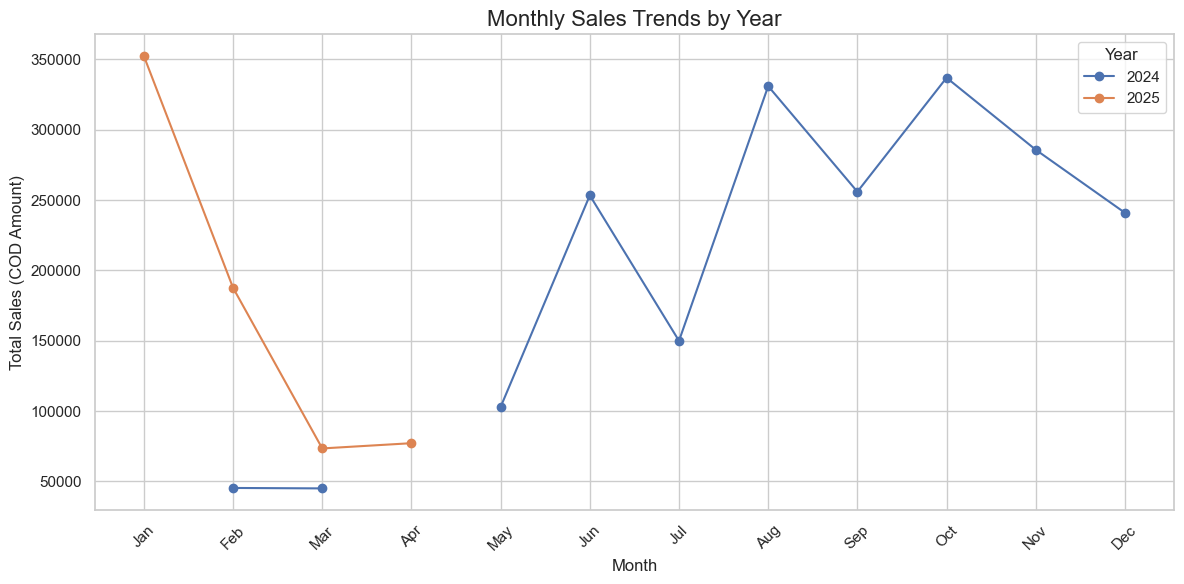

In [112]:

df_cleaned['Year'] = df_cleaned['Created At'].dt.year
df_cleaned['Month'] = df_cleaned['Created At'].dt.month
monthly_sales = df_cleaned.groupby(['Year', 'Month'])['COD Amount'].sum().reset_index()

# Pivot the data for better visualization
monthly_sales_pivot = monthly_sales.pivot(index='Month', columns='Year', values='COD Amount')

# Plot the data
plt.figure(figsize=(12, 6))
monthly_sales_pivot.plot(kind='line', marker='o', ax=plt.gca())
plt.title("Monthly Sales Trends by Year", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales (COD Amount)", fontsize=12)
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], rotation=45)
plt.legend(title="Year")
plt.grid(True)
plt.tight_layout()
plt.show()